In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast

file = pd.read_excel('C:/Data_/excel/data_jobs_salary_all.xlsx',sheet_name='maaz_1')
file['job_posted_month']=pd.to_datetime(file['job_posted_date']).dt.strftime('%b')
file['job_skills']=file['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

print(file.info())

<class 'pandas.DataFrame'>
RangeIndex: 32672 entries, 0 to 32671
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   job_title_short        32672 non-null  str           
 1   job_title              32672 non-null  str           
 2   job_location           32317 non-null  str           
 3   job_via                32662 non-null  str           
 4   job_schedule_type      32531 non-null  str           
 5   job_work_from_home     32672 non-null  bool          
 6   search_location        32672 non-null  str           
 7   job_posted_date        32672 non-null  datetime64[us]
 8   job_no_degree_mention  32672 non-null  bool          
 9   job_health_insurance   32672 non-null  bool          
 10  job_country            32672 non-null  str           
 11  salary_rate            32672 non-null  str           
 12  salary_year_avg        22036 non-null  float64       
 13  salary_hour_

In [26]:
file_skill=file.copy()
file_skill=file_skill.explode('job_skills')
skill_counts=file_skill.groupby(['job_title_short','job_skills']).size()
file_skill_counts=skill_counts.reset_index(name='skill_count')
file_skill_counts=file_skill_counts.sort_values(by='skill_count',ascending=False)
file_skill_counts



,job_title_short,job_skills,skill_count
725,Data Scientist,python,6007
366,Data Analyst,sql,5033
561,Data Engineer,sql,4718
529,Data Engineer,python,4433
757,Data Scientist,sql,4268
...,...,...,...
1542,Software Engineer,svn,1
4,Business Analyst,apl,1
1547,Software Engineer,terminal,1
1549,Software Engineer,trello,1


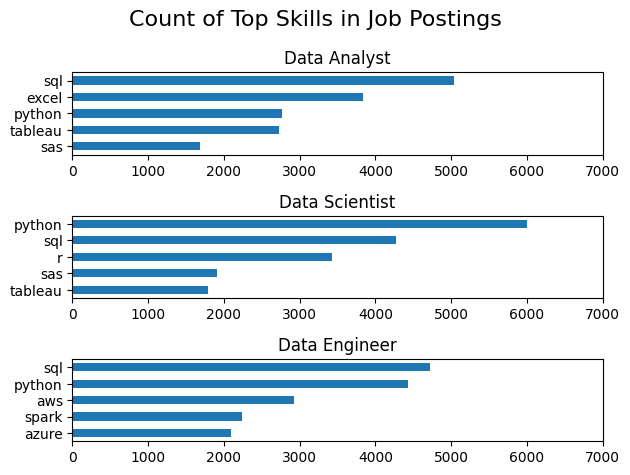

In [40]:
job_titles=['Data Analyst','Data Scientist','Data Engineer']

fig, ax=plt.subplots(3,1)


for i, job_title in enumerate(job_titles):
    file_plot=file_skill_counts[file_skill_counts['job_title_short']==job_title].head()
    file_plot.plot(kind='barh',x='job_skills',y='skill_count',ax=ax[i],title=job_title)

    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0,7000)

fig.suptitle('Count of Top Skills in Job Postings',fontsize=16)
fig.tight_layout()